In [1]:
import sys, os, json, torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../..'))
from DL.models import CustomClassifierFromConfig
from DL.historical_trash.trainer import ModelTrainer
from DL.historical_trash.visualize import plot_confusion_matrices
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Подготовка данных (только кириллица с жесткой перспективой для скорости)
perspective_transform = T.RandomPerspective(distortion_scale=0.5, p=0.8)

class SyntheticCyrillicDataset(Dataset):
    def __init__(self, num_samples, seed, transform=None):
        self.num_samples = num_samples
        self.generator = LowerCaseLettersGenerator(seed=seed)
        self.char_to_idx = {char: idx for idx, char in enumerate(self.generator.ALLOWS_SYMBOLS)}
        self.idx_to_char = {idx: char for char, idx in self.char_to_idx.items()}
        self.transform = transform

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        img_np, label_char = self.generator.generate()
        img_tensor = torch.from_numpy(img_np).float().unsqueeze(0) / 255.0
        if self.transform: img_tensor = self.transform(img_tensor)
        return img_tensor, self.char_to_idx[label_char]

train_loader = DataLoader(SyntheticCyrillicDataset(60000, 42, perspective_transform), batch_size=256, shuffle=True)
test_loader = DataLoader(SyntheticCyrillicDataset(15000, 999, perspective_transform), batch_size=256, shuffle=False)

In [2]:
def run_advanced_experiment(name: str, config_kwargs: dict, trainer_kwargs: dict):
    with open('../configs/lenet/lenet_4kb.json', 'r') as f:
        config = json.load(f)
    config['num_classes'] = len(train_loader.dataset.char_to_idx)

    model = CustomClassifierFromConfig(config, **config_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trainer = ModelTrainer(model, optimizer, nn.CrossEntropyLoss(), device, **trainer_kwargs)
    print(f"\n[{name}] Обучение начато...")
    trainer.fit(train_loader, test_loader, epochs=10) # 10 эпох достаточно для проверки концепций

    print(f"[{name}] Матрица ошибок:")
    plot_confusion_matrices(model, model, test_loader, test_loader.dataset, device)


[2. Инженерия признаков (Pixel Count)] Обучение начато...
Epoch 1/10


Train Loss: 2.4594 | Train Acc: 0.3925 | BG Loss: 0.0269
Val Loss: 1.6432 | Val Acc: 0.6139

Epoch 2/10


Train Loss: 1.3018 | Train Acc: 0.6838 | BG Loss: 0.0131
Val Loss: 1.0105 | Val Acc: 0.7502

Epoch 3/10


Train Loss: 0.8645 | Train Acc: 0.7849 | BG Loss: 0.0131
Val Loss: 0.7410 | Val Acc: 0.8127

Epoch 4/10


Train Loss: 0.6558 | Train Acc: 0.8343 | BG Loss: 0.0125
Val Loss: 0.5968 | Val Acc: 0.8510

Epoch 5/10


...

Train Loss: 0.4698 | Train Acc: 0.8788 | BG Loss: 0.0114
Val Loss: 0.4853 | Val Acc: 0.8704

Epoch 7/10


Train Loss: 0.4229 | Train Acc: 0.8886 | BG Loss: 0.0107
Val Loss: 0.3980 | Val Acc: 0.8959

Epoch 8/10


Train Loss: 0.3829 | Train Acc: 0.8971 | BG Loss: 0.0105
Val Loss: nan | Val Acc: 0.9022

Epoch 9/10


Train Loss: 0.3554 | Train Acc: 0.9056 | BG Loss: 0.0081
Val Loss: 0.3333 | Val Acc: 0.9130

Epoch 10/10


Train Loss: 0.3397 | Train Acc: 0.9083 | BG Loss: 0.0078
Val Loss: 0.3274 | Val Acc: 0.9086

[2. Инженерия признаков (Pixel Count)] Матрица ошибок:


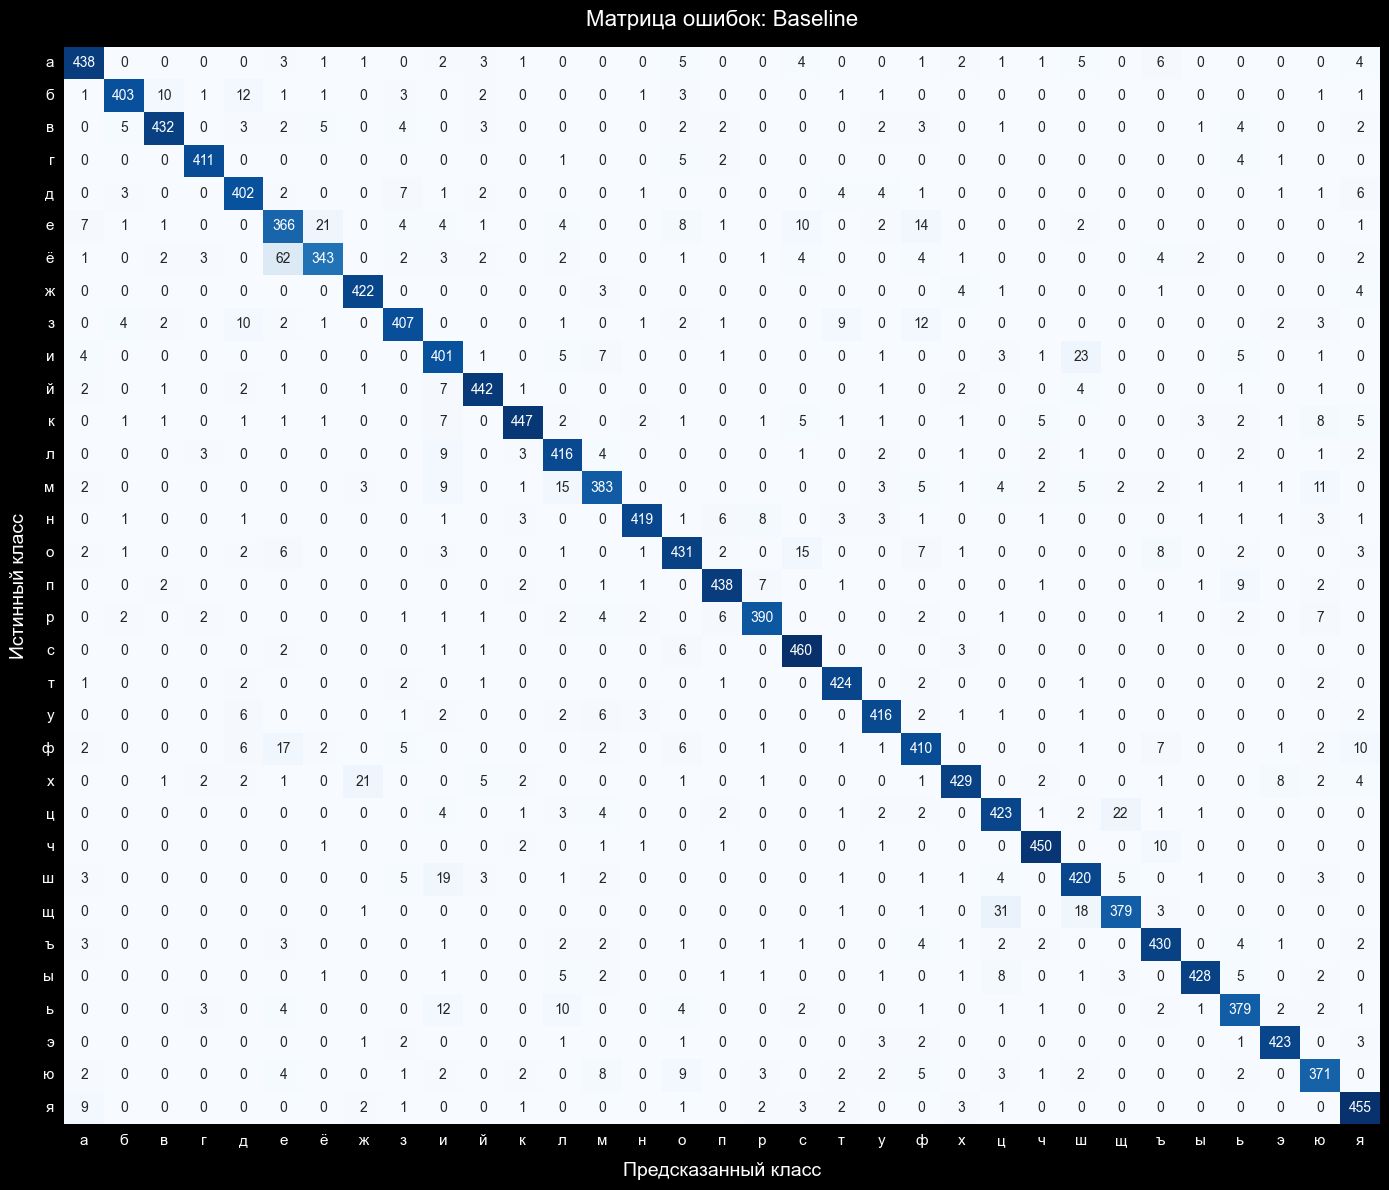

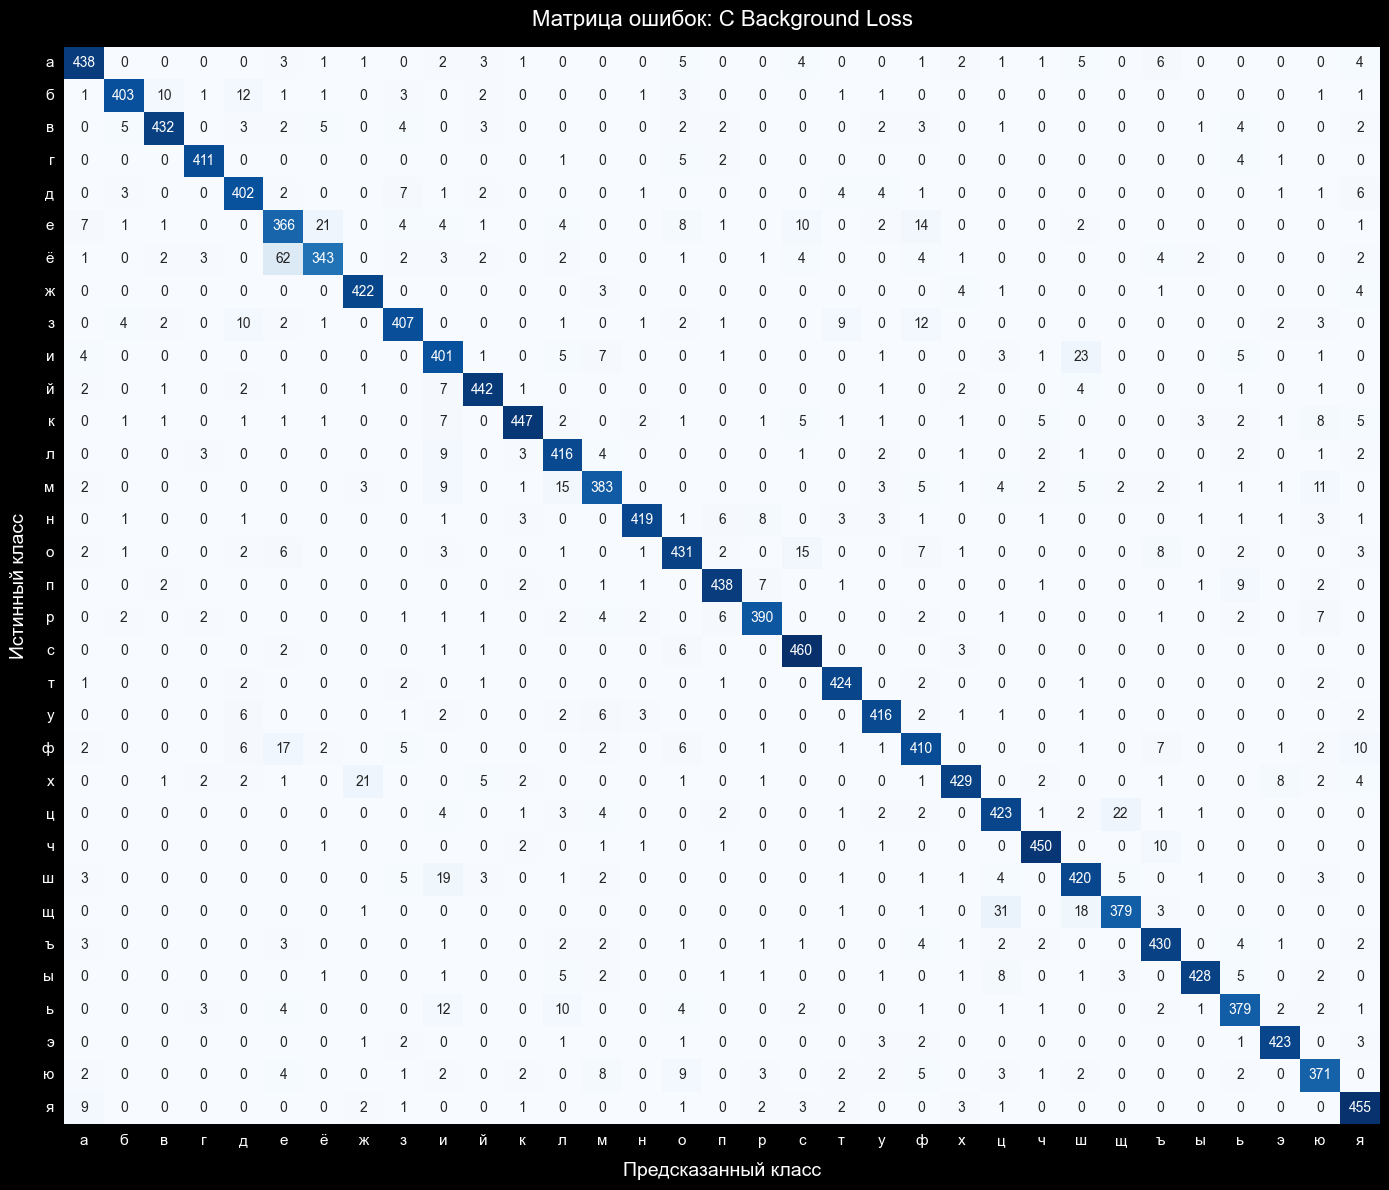

In [3]:
# 1. Гипотеза "Плотность пикселей"
run_advanced_experiment(
    "2. Инженерия признаков (Pixel Count)",
    config_kwargs={'use_pixel_count': True},
    trainer_kwargs={'use_background_loss': True, 'bg_loss_alpha': 15.0, 'bg_loss_n': 2}
)


[3. Metric Learning (ArcFace)] Обучение начато...
Epoch 1/10


Train Loss: 6.8279 | Train Acc: 0.0032 | BG Loss: 0.0054
Val Loss: 1.7525 | Val Acc: 0.5515

Epoch 2/10


Train Loss: 5.1282 | Train Acc: 0.0433 | BG Loss: 0.0031
Val Loss: 1.1651 | Val Acc: 0.6912

Epoch 3/10


Train Loss: 4.1969 | Train Acc: 0.1185 | BG Loss: 0.0016
Val Loss: 0.9230 | Val Acc: 0.7555

Epoch 4/10


Train Loss: 3.6295 | Train Acc: 0.1956 | BG Loss: 0.0018
Val Loss: 0.8094 | Val Acc: 0.7799

Epoch 5/10


...

Train Loss: 3.0777 | Train Acc: 0.2770 | BG Loss: 0.0010
Val Loss: 0.7214 | Val Acc: 0.8019

Epoch 7/10


Train Loss: 2.9644 | Train Acc: 0.2883 | BG Loss: 0.0006
Val Loss: 0.6871 | Val Acc: 0.8079

Epoch 8/10


Train Loss: 2.9093 | Train Acc: 0.2951 | BG Loss: 0.0010
Val Loss: 0.6678 | Val Acc: 0.8177

Epoch 9/10


Train Loss: 2.8626 | Train Acc: 0.3013 | BG Loss: 0.0004
Val Loss: 0.6515 | Val Acc: 0.8163

Epoch 10/10


Train Loss: 2.8341 | Train Acc: 0.3061 | BG Loss: 0.0005
Val Loss: 0.6599 | Val Acc: 0.8151

[3. Metric Learning (ArcFace)] Матрица ошибок:


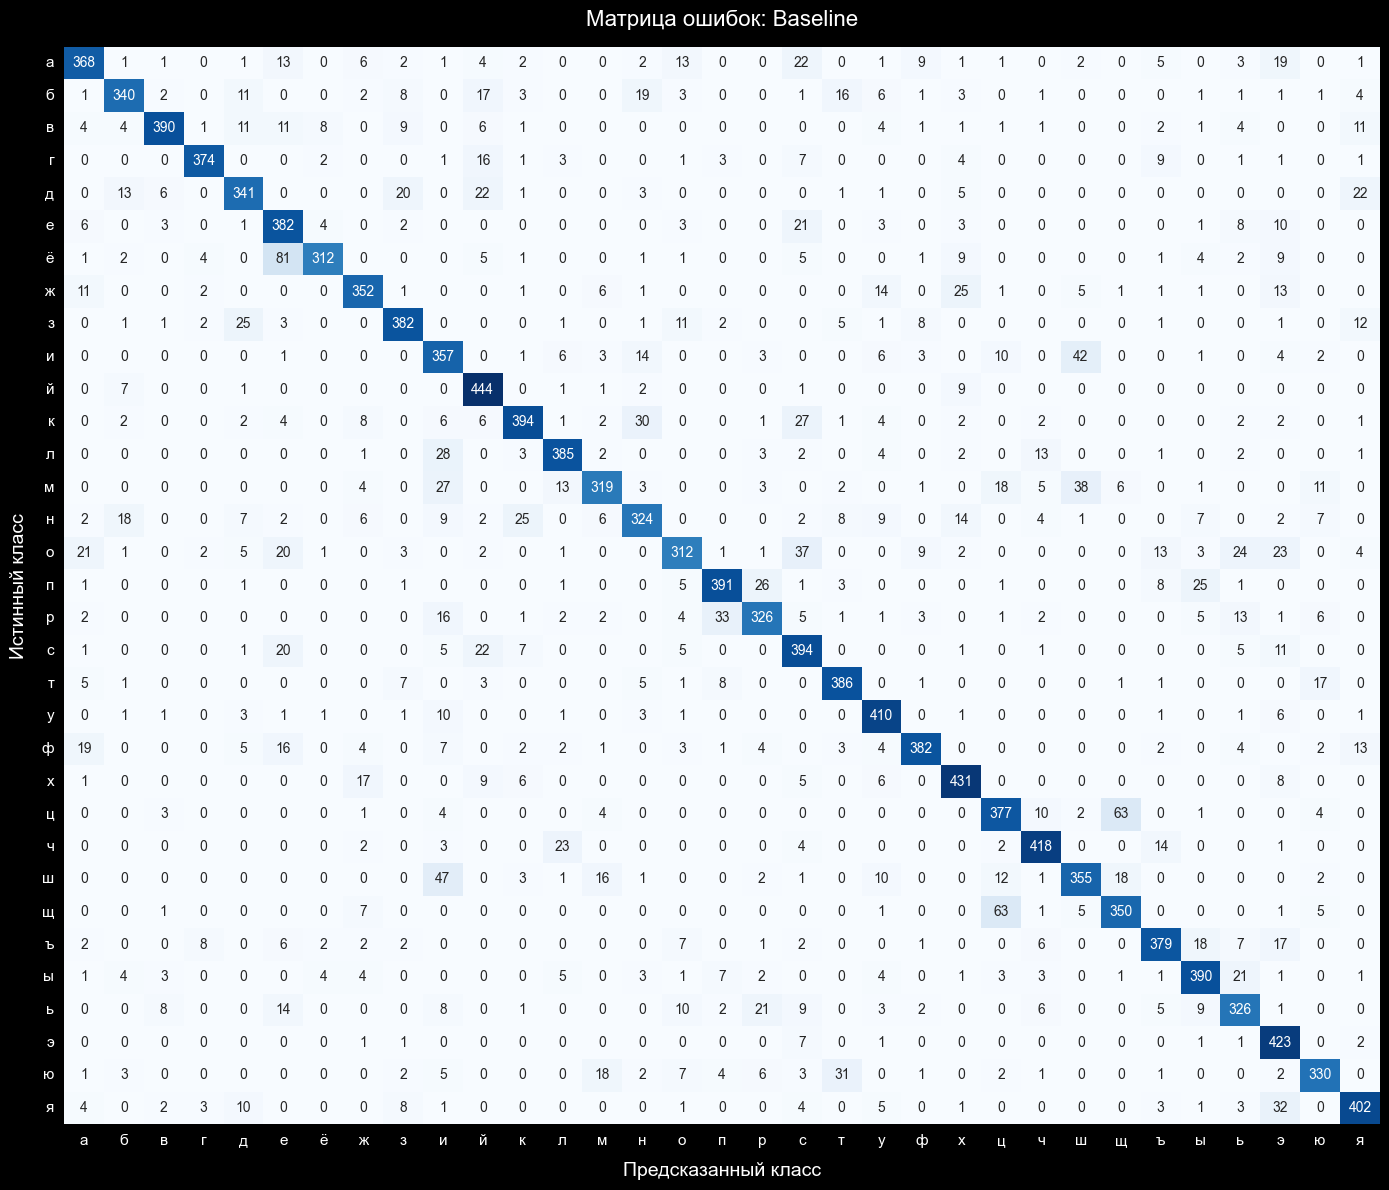

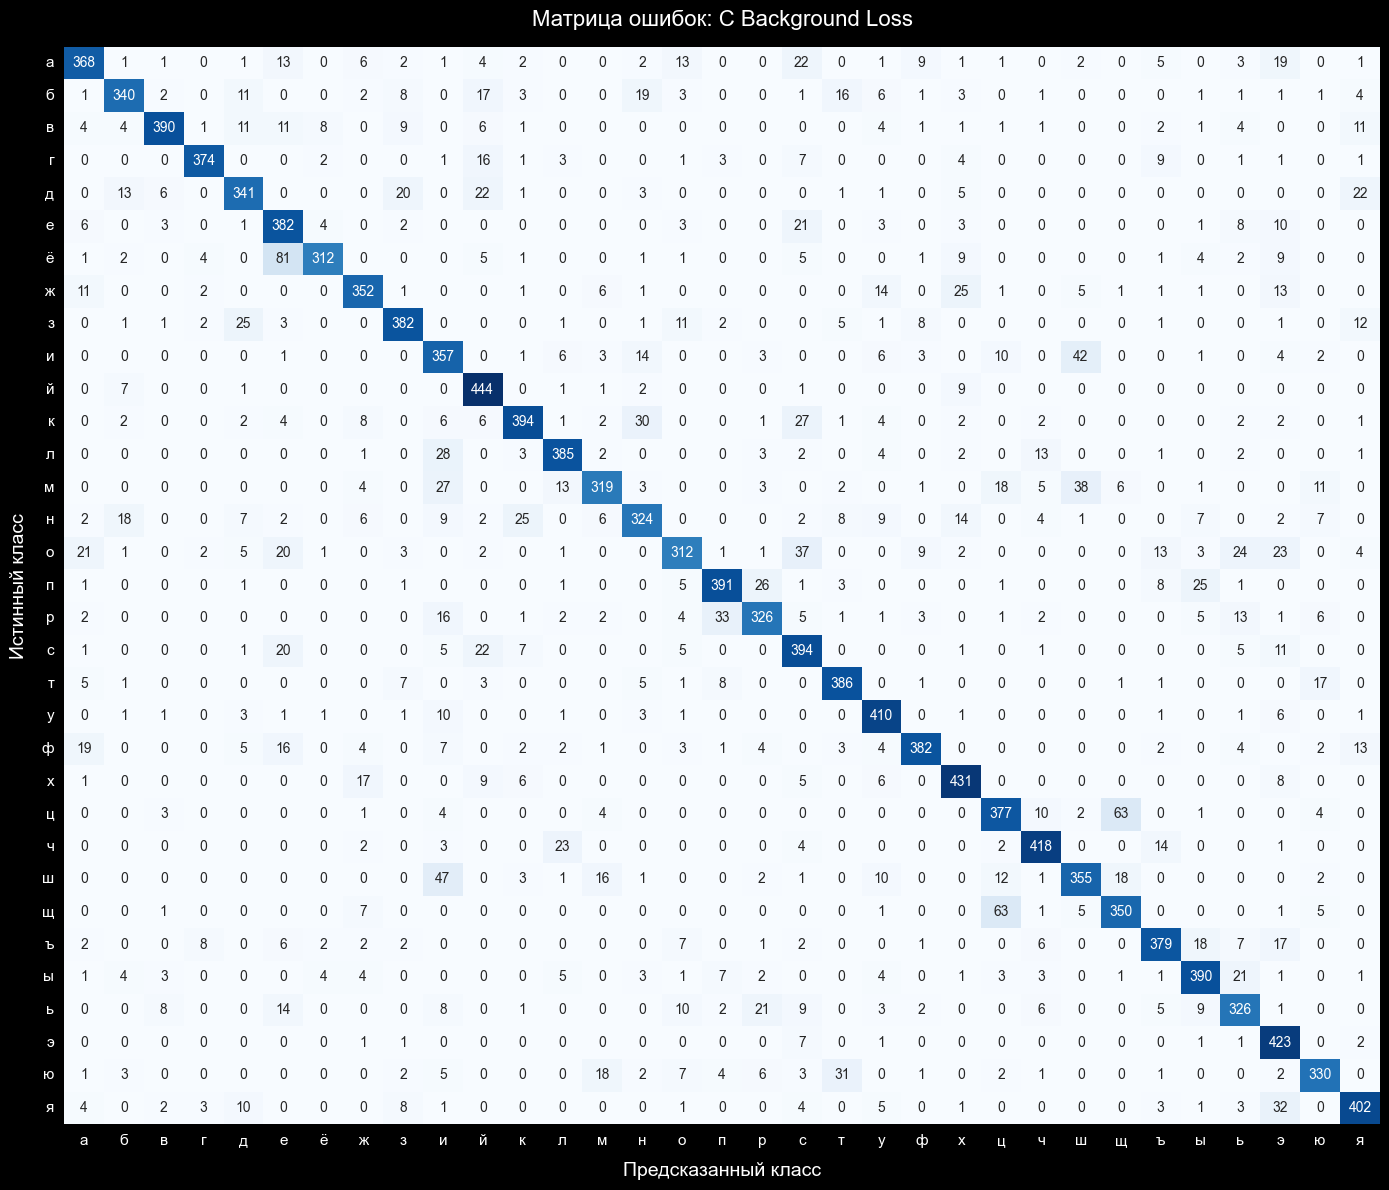

In [3]:
# 2. Гипотеза "Метрическое обучение" (ArcFace)
run_advanced_experiment(
    "3. Metric Learning (ArcFace)",
    config_kwargs={'use_arcface': True},
    trainer_kwargs={'use_background_loss': True, 'bg_loss_alpha': 15.0, 'bg_loss_n': 2}
)



[4. Латентная Адверсариальная Регуляризация (GAN Loss)] Обучение начато...
Epoch 1/10


Train Loss: 2.3446 | Train Acc: 0.4386 | BG Loss: 0.3198
Val Loss: 1.4519 | Val Acc: 0.6754

Epoch 2/10


Train Loss: 1.2095 | Train Acc: 0.7316 | BG Loss: 0.0001
Val Loss: 1.0988 | Val Acc: 0.7672

Epoch 3/10


Train Loss: 1.0857 | Train Acc: 0.7786 | BG Loss: 0.0005
Val Loss: 1.1064 | Val Acc: 0.7871

Epoch 4/10


Train Loss: 1.0812 | Train Acc: 0.7922 | BG Loss: 0.0000
Val Loss: 1.0450 | Val Acc: 0.7924

Epoch 5/10


...

Train Loss: 0.8816 | Train Acc: 0.8165 | BG Loss: 0.0001
Val Loss: 0.8325 | Val Acc: 0.8253

Epoch 7/10


Train Loss: 0.7872 | Train Acc: 0.8329 | BG Loss: 0.0001
Val Loss: 0.7630 | Val Acc: 0.8339

Epoch 8/10


Train Loss: 0.7152 | Train Acc: 0.8413 | BG Loss: 0.0001
Val Loss: 0.6806 | Val Acc: 0.8477

Epoch 9/10


Train Loss: 0.6543 | Train Acc: 0.8497 | BG Loss: 0.0003
Val Loss: 0.6258 | Val Acc: 0.8543

Epoch 10/10


Train Loss: 0.6096 | Train Acc: 0.8549 | BG Loss: 0.0005
Val Loss: 0.5969 | Val Acc: 0.8558

[4. Латентная Адверсариальная Регуляризация (GAN Loss)] Матрица ошибок:


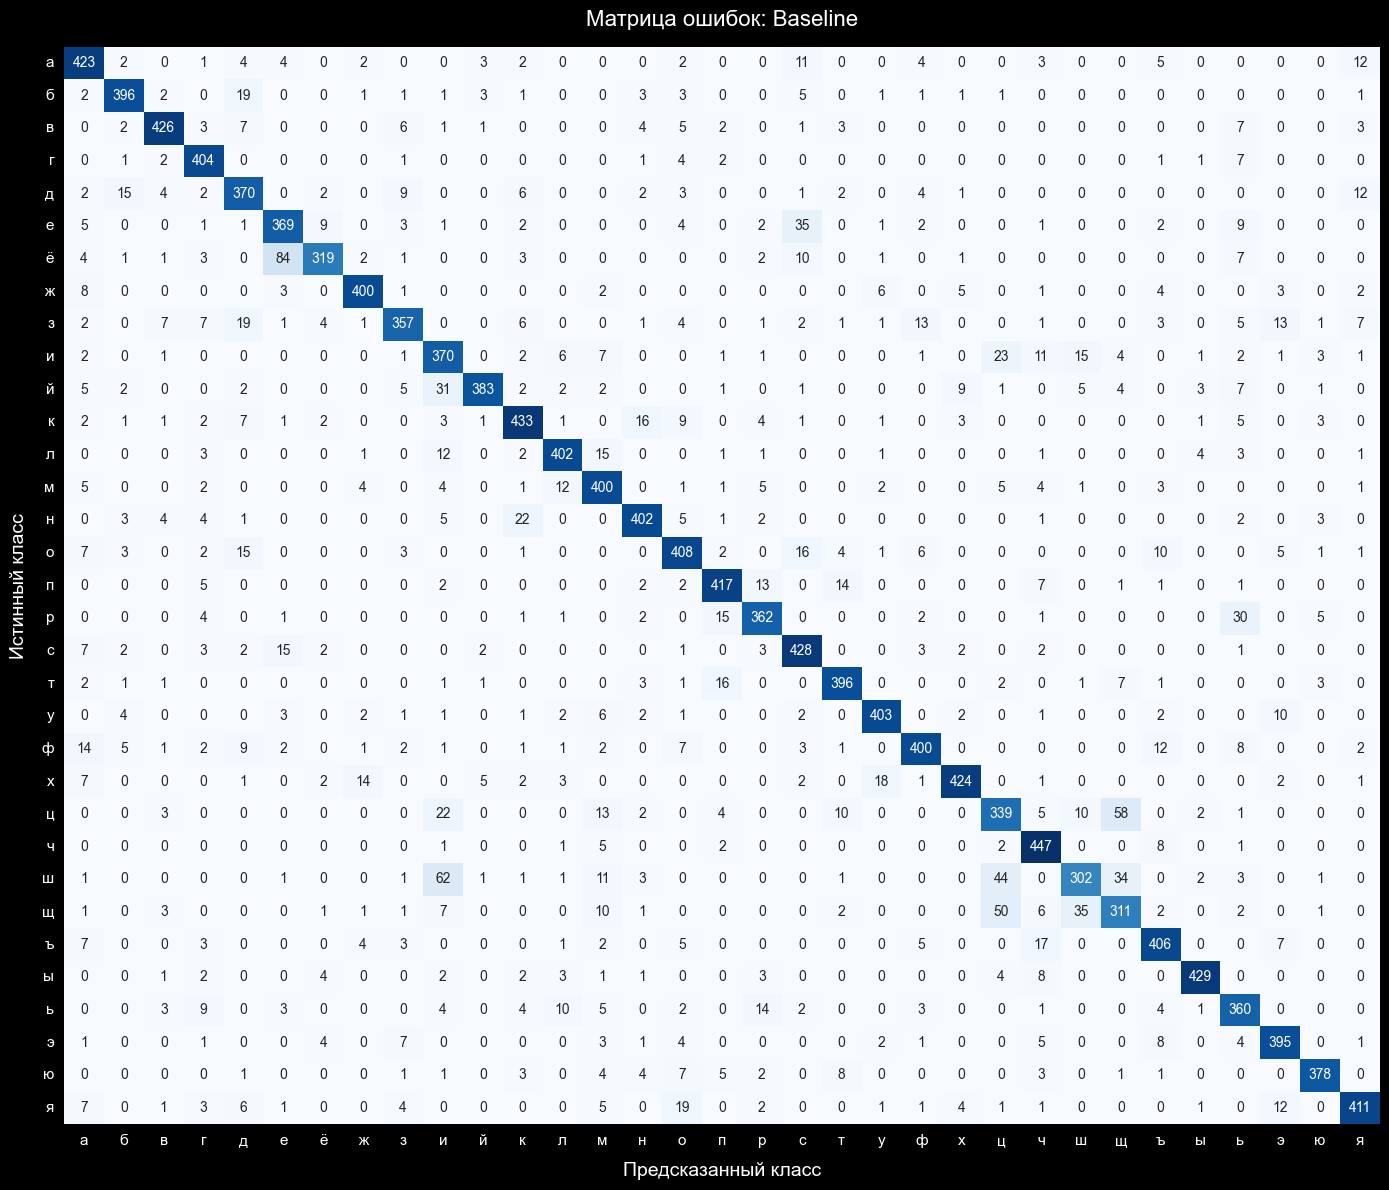

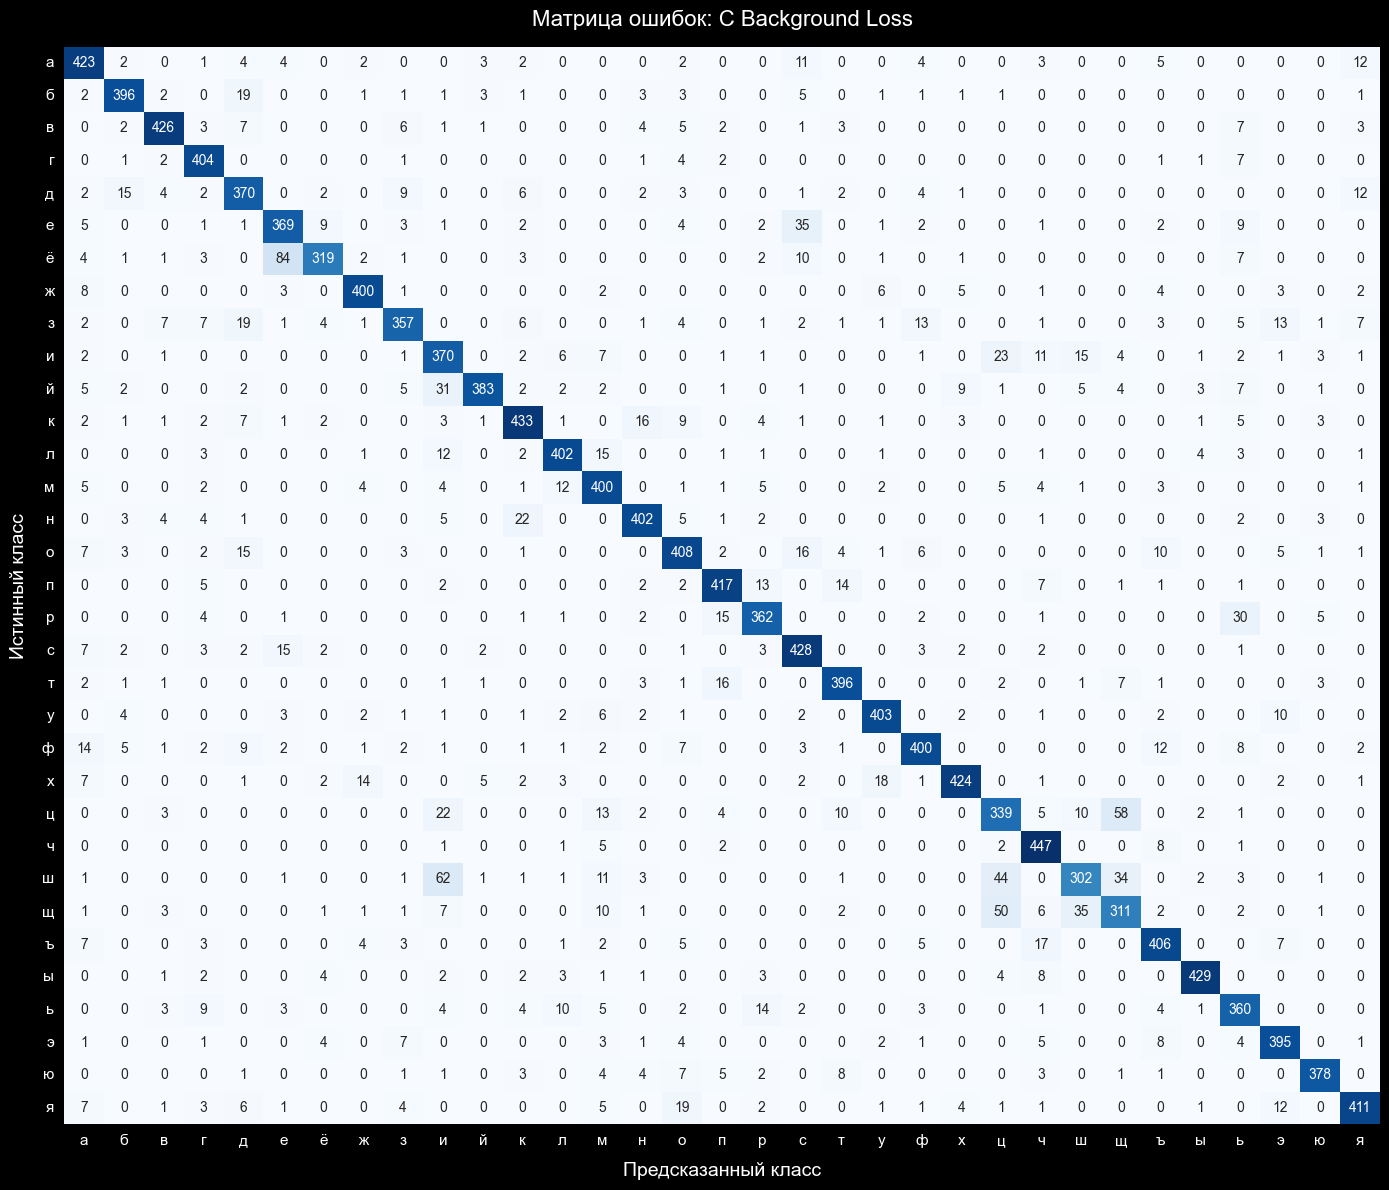

In [3]:
# 3. Гипотеза "Латентный GAN"
run_advanced_experiment(
    "4. Латентная Адверсариальная Регуляризация (GAN Loss)",
    config_kwargs={},
    trainer_kwargs={'use_background_loss': True, 'bg_loss_alpha': 15.0, 'bg_loss_n': 2, 'use_gan_loss': True}
)


[1. Эталон (Только BG Loss)] Обучение начато...
Epoch 1/10


Train Loss: 2.4049 | Train Acc: 0.4209 | BG Loss: 0.0785
Val Loss: 1.5266 | Val Acc: 0.6417

Epoch 2/10


Train Loss: 1.1947 | Train Acc: 0.7115 | BG Loss: 0.0080
Val Loss: 0.9529 | Val Acc: 0.7580

Epoch 3/10


Train Loss: 0.8433 | Train Acc: 0.7814 | BG Loss: 0.0092
Val Loss: 0.7444 | Val Acc: 0.8044

Epoch 4/10


Train Loss: 0.6903 | Train Acc: 0.8147 | BG Loss: 0.0088
Val Loss: 0.6283 | Val Acc: 0.8289

Epoch 5/10


...

Train Loss: 0.5164 | Train Acc: 0.8589 | BG Loss: 0.0081
Val Loss: 0.4929 | Val Acc: 0.8627

Epoch 7/10


Train Loss: 0.4715 | Train Acc: 0.8719 | BG Loss: 0.0084
Val Loss: 0.4509 | Val Acc: 0.8780

Epoch 8/10


Train Loss: 0.4281 | Train Acc: 0.8818 | BG Loss: 0.0076
Val Loss: 0.4123 | Val Acc: 0.8866

Epoch 9/10


Train Loss: 0.4003 | Train Acc: 0.8892 | BG Loss: 0.0069
Val Loss: 0.3927 | Val Acc: 0.8921

Epoch 10/10


Train Loss: 0.3832 | Train Acc: 0.8925 | BG Loss: 0.0073
Val Loss: 0.3673 | Val Acc: 0.8959

[1. Эталон (Только BG Loss)] Матрица ошибок:


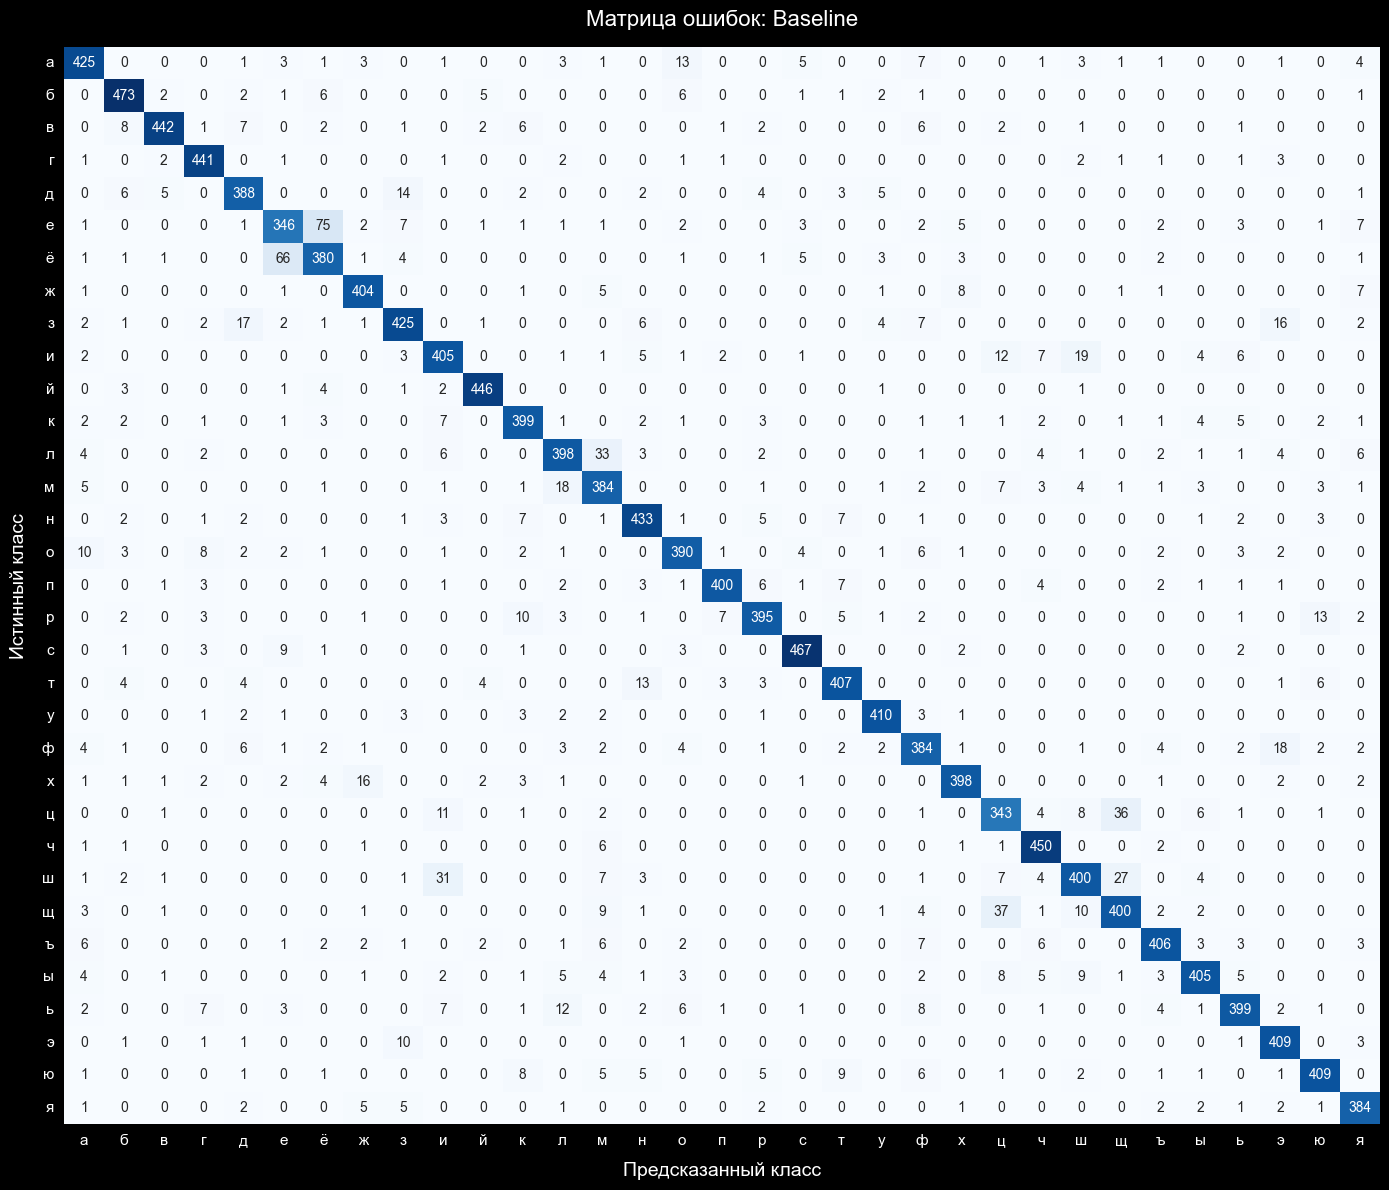

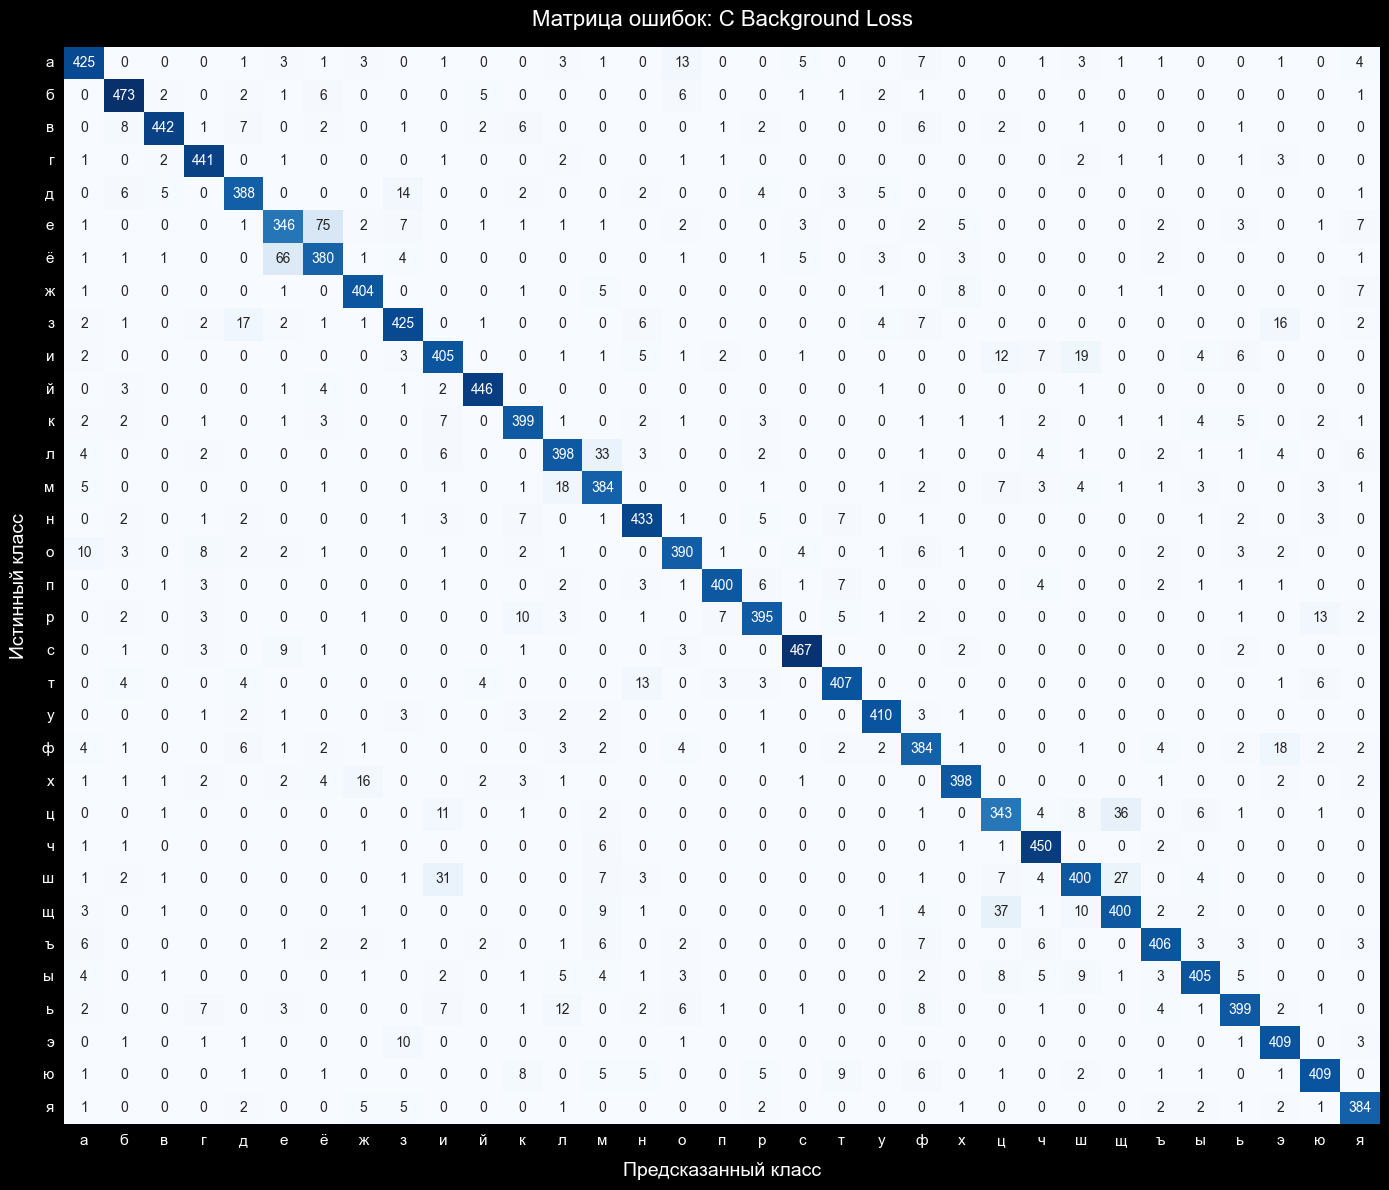

In [4]:
# 4. Baseline + BG Loss (Эталон для сравнения)
run_advanced_experiment(
    "1. Эталон (Только BG Loss)",
    config_kwargs={},
    trainer_kwargs={'use_background_loss': True, 'bg_loss_alpha': 15.0, 'bg_loss_n': 2}
)